<a href="https://colab.research.google.com/github/nandinisingh66/CSET343/blob/main/AIinHealthcare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn wfdb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
print("Environment setup done!!")

Environment setup done!!


In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# Fetch UCI Heart Disease dataset
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

print("Dataset downloaded successfully!")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Dataset downloaded successfully!
Features shape: (303, 13)
Target shape: (303, 1)


In [ ]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [ ]:
y.head()

,num
0,0
1,2
2,1
3,0
4,0


In [ ]:
print("Feature Columns: ")
print(X.columns.tolist())

Feature Columns: 
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB


In [ ]:
print("missing values in each column: ")
print(X.isnull().sum())

missing values in each column: 
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64


In [ ]:
print("Target Value: ")
print(y.value_counts())


Target Value: 
num
0      164
1       55
2       36
3       35
4       13
Name: count, dtype: int64


In [ ]:
df=X.copy()
df["Target"]=y.iloc[:,0]
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [ ]:
df.shape

(303, 14)

In [ ]:
df["Target"]=(df["Target"]>0).astype(int)
print(df["Target"].value_counts())

Target
0    164
1    139
Name: count, dtype: int64


In [ ]:
print("Final dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nTarget distribution:")
print(df["Target"].value_counts())

Final dataset shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0



Target distribution:
Target
0    164
1    139
Name: count, dtype: int64


In [ ]:
# Convert possible non-numeric missing markers to NaN
df = df.replace("?", np.nan)

# Convert all columns to numeric where possible
df = df.apply(pd.to_numeric, errors="coerce")

print("Missing values after conversion:")
print(df.isnull().sum())

Missing values after conversion:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
Target      0
dtype: int64


In [ ]:
# Fill missing numerical values with column median
for column in df.columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].median())

print("Remaining missing values:")
print(df.isnull().sum().sum())

Remaining missing values:
0


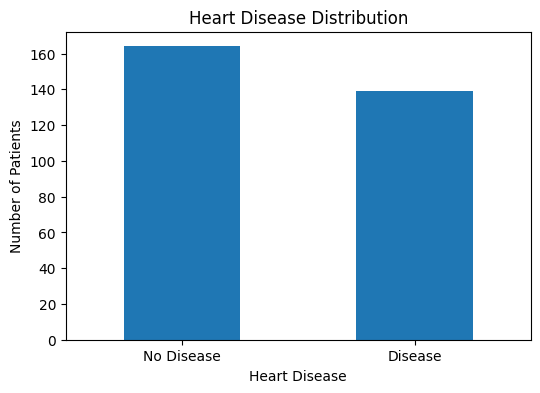

In [ ]:
plt.figure(figsize=(6, 4))

df["Target"].value_counts().sort_index().plot(kind="bar")

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["No Disease", "Disease"], rotation=0)

plt.show()

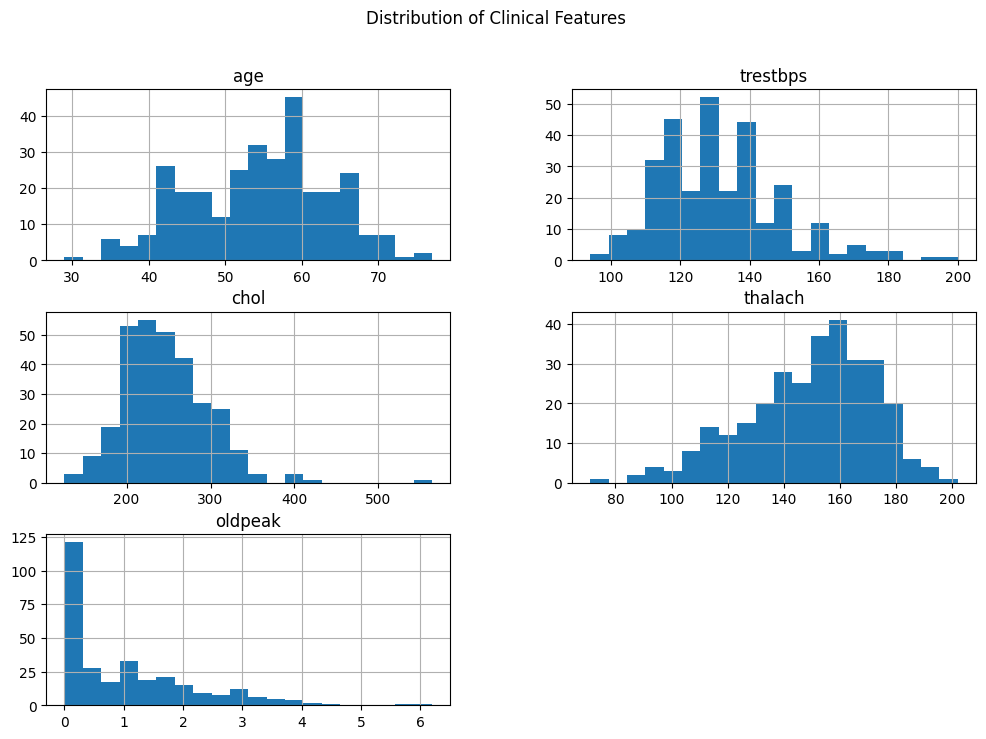

In [ ]:
df[["age", "trestbps", "chol", "thalach", "oldpeak"]].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle("Distribution of Clinical Features")
plt.show()

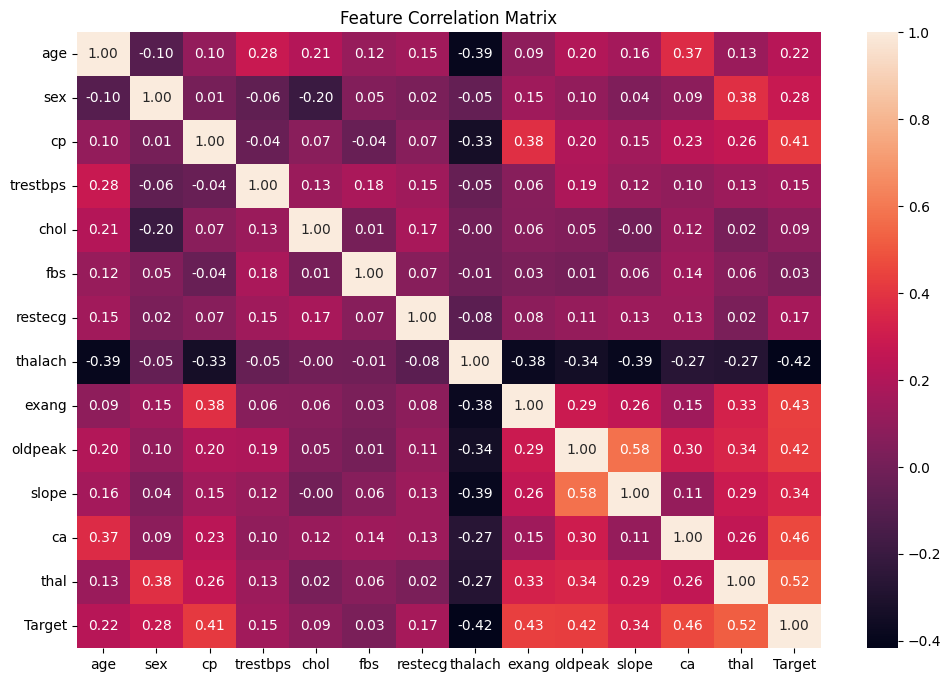

In [ ]:
plt.figure(figsize=(12, 8))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
X = df.drop("Target", axis=1)
y = df["Target"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 242
Testing samples: 61


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))

Accuracy: 0.8689


In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", round(roc_auc, 4))

ROC-AUC: 0.9524


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[27  6]
 [ 2 26]]


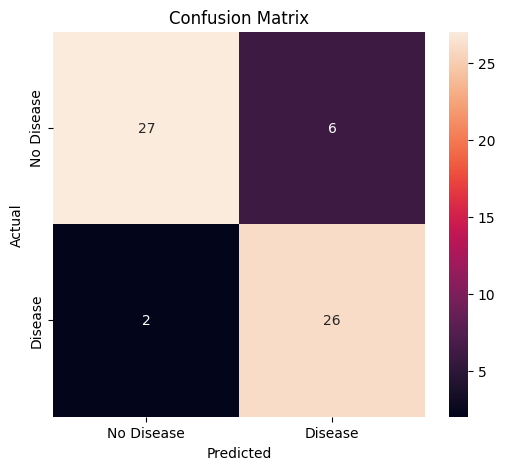

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

print("WFDB imported successfully!")

WFDB imported successfully!


In [ ]:
# Download and load ECG record 100

record = wfdb.rdrecord(
    "100",
    pn_dir="mitdb"
)

print("ECG record loaded successfully!")

ECG record loaded successfully!


In [ ]:
print("Number of samples:", record.sig_len)
print("Sampling frequency:", record.fs)
print("Number of channels:", record.n_sig)
print("Signal names:", record.sig_name)

Number of samples: 650000
Sampling frequency: 360
Number of channels: 2
Signal names: ['MLII', 'V5']


In [ ]:
record.p_signal

array([[-0.145, -0.065],
       [-0.145, -0.065],
       [-0.145, -0.065],
       ...,
       [-0.675, -0.365],
       [-0.765, -0.335],
       [-1.28 ,  0.   ]])

In [ ]:
signal = record.p_signal

print("Signal shape:", signal.shape)

Signal shape: (650000, 2)


In [ ]:
print(signal[:10])

[[-0.145 -0.065]
 [-0.145 -0.065]
 [-0.145 -0.065]
 [-0.145 -0.065]
 [-0.145 -0.065]
 [-0.145 -0.065]
 [-0.145 -0.065]
 [-0.145 -0.065]
 [-0.12  -0.08 ]
 [-0.135 -0.08 ]]


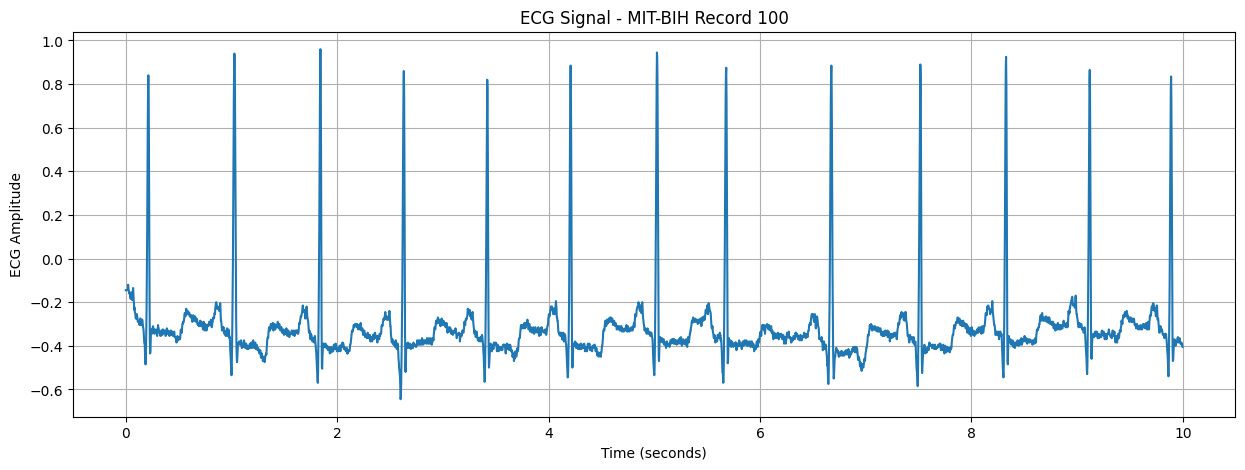

In [ ]:
# Sampling frequency
fs = record.fs

# Number of samples corresponding to 10 seconds
samples_10_sec = int(10 * fs)

# Time axis
time = np.arange(samples_10_sec) / fs

# Use the first ECG channel
ecg = signal[:samples_10_sec, 0]

# Plot
plt.figure(figsize=(15, 5))

plt.plot(time, ecg)

plt.title("ECG Signal - MIT-BIH Record 100")
plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")

plt.grid()
plt.show()

In [ ]:
# Load annotations for record 100

annotation = wfdb.rdann(
    "100",
    "atr",
    pn_dir="mitdb"
)

print("Annotations loaded successfully!")

Annotations loaded successfully!


In [ ]:
print("Number of annotations:", len(annotation.sample))
print("First 20 annotation samples:")
print(annotation.sample[:20])

print("\nFirst 20 annotation symbols:")
print(annotation.symbol[:20])

Number of annotations: 2274
First 20 annotation samples:
[  18   77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560
 3862 4170 4466 4764 5060 5346]

First 20 annotation symbols:
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


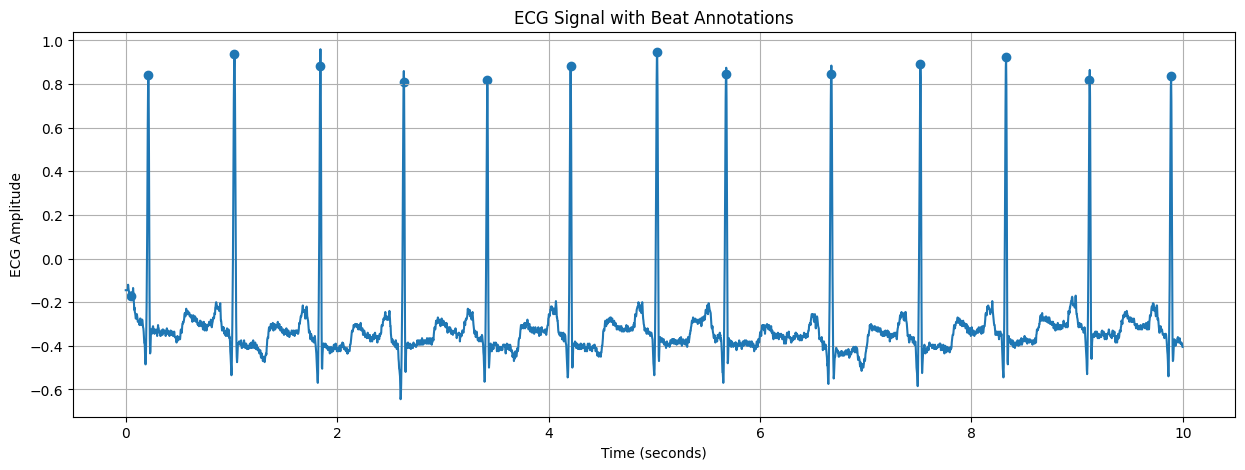

In [ ]:
# Select first 10 seconds
annotation_samples = annotation.sample[
    annotation.sample < samples_10_sec
]

annotation_symbols = [
    annotation.symbol[i]
    for i, sample in enumerate(annotation.sample)
    if sample < samples_10_sec
]

# Convert annotation sample positions to seconds
annotation_times = annotation_samples / fs

plt.figure(figsize=(15, 5))

# ECG waveform
plt.plot(time, ecg)

# Beat locations
plt.scatter(
    annotation_times,
    ecg[annotation_samples],
    marker="o"
)

plt.title("ECG Signal with Beat Annotations")
plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")

plt.grid()
plt.show()

In [ ]:
# Get beat locations in samples
beat_samples = annotation.sample

# Convert samples to seconds
beat_times = beat_samples / fs

# Calculate intervals between consecutive beats
beat_intervals = np.diff(beat_times)

print("First 20 beat intervals (seconds):")
print(beat_intervals[:20])

First 20 beat intervals (seconds):
[0.16388889 0.81388889 0.81111111 0.78888889 0.79166667 0.78888889
 0.81666667 0.65277778 0.99444444 0.84444444 0.81111111 0.78888889
 0.77222222 0.83888889 0.85555556 0.82222222 0.82777778 0.82222222
 0.79444444 0.79722222]


In [ ]:
# Calculate average beat interval
mean_rr = np.mean(beat_intervals)

# Convert RR interval to heart rate
average_heart_rate = 60 / mean_rr

print("Average RR interval:", round(mean_rr, 3), "seconds")
print("Estimated average heart rate:", round(average_heart_rate, 2), "BPM")

Average RR interval: 0.794 seconds
Estimated average heart rate: 75.54 BPM


In [ ]:
# Basic RR interval statistics

rr_mean = np.mean(beat_intervals)
rr_std = np.std(beat_intervals)
rr_min = np.min(beat_intervals)
rr_max = np.max(beat_intervals)

print("RR Interval Statistics")
print("----------------------")
print("Mean:", round(rr_mean, 4), "seconds")
print("Standard deviation:", round(rr_std, 4), "seconds")
print("Minimum:", round(rr_min, 4), "seconds")
print("Maximum:", round(rr_max, 4), "seconds")

RR Interval Statistics
----------------------
Mean: 0.7943 seconds
Standard deviation: 0.0506 seconds
Minimum: 0.1639 seconds
Maximum: 1.1306 seconds


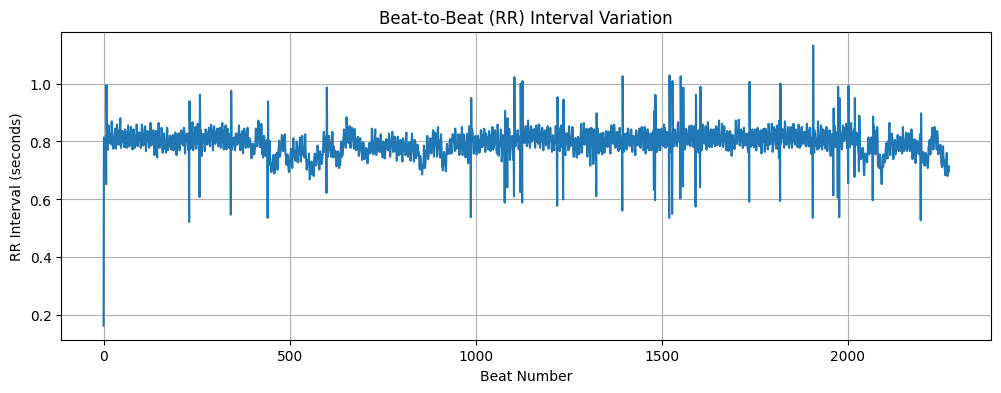

In [ ]:
plt.figure(figsize=(12, 4))

plt.plot(beat_intervals)

plt.title("Beat-to-Beat (RR) Interval Variation")
plt.xlabel("Beat Number")
plt.ylabel("RR Interval (seconds)")

plt.grid()
plt.show()

In [42]:
clinical_note = """
The patient is a 58-year-old male presenting with chest pain and shortness of breath.
The patient reports chest discomfort during physical activity for the past two weeks.
He has a history of high blood pressure and elevated cholesterol.
The patient also reports occasional fatigue and dizziness.
An ECG examination is recommended for further evaluation.
"""

print(clinical_note)


The patient is a 58-year-old male presenting with chest pain and shortness of breath.
The patient reports chest discomfort during physical activity for the past two weeks.
He has a history of high blood pressure and elevated cholesterol.
The patient also reports occasional fatigue and dizziness.
An ECG examination is recommended for further evaluation.



In [43]:
text = clinical_note.lower()

print(text)


the patient is a 58-year-old male presenting with chest pain and shortness of breath.
the patient reports chest discomfort during physical activity for the past two weeks.
he has a history of high blood pressure and elevated cholesterol.
the patient also reports occasional fatigue and dizziness.
an ecg examination is recommended for further evaluation.



In [44]:
import re

tokens = re.findall(r'\b[a-z]+\b', text)

print("Tokens:")
print(tokens)

Tokens:
['the', 'patient', 'is', 'a', 'year', 'old', 'male', 'presenting', 'with', 'chest', 'pain', 'and', 'shortness', 'of', 'breath', 'the', 'patient', 'reports', 'chest', 'discomfort', 'during', 'physical', 'activity', 'for', 'the', 'past', 'two', 'weeks', 'he', 'has', 'a', 'history', 'of', 'high', 'blood', 'pressure', 'and', 'elevated', 'cholesterol', 'the', 'patient', 'also', 'reports', 'occasional', 'fatigue', 'and', 'dizziness', 'an', 'ecg', 'examination', 'is', 'recommended', 'for', 'further', 'evaluation']


In [45]:
print("Number of tokens:", len(tokens))

Number of tokens: 55


In [46]:
# Basic stop-word list

stop_words = {
    "the", "a", "an", "is", "are", "was", "were",
    "with", "and", "or", "for", "of", "to", "in",
    "on", "has", "have", "he", "she", "his", "her",
    "this", "that", "patient"
}

filtered_tokens = [
    word for word in tokens
    if word not in stop_words
]

print("Filtered tokens:")
print(filtered_tokens)

Filtered tokens:
['year', 'old', 'male', 'presenting', 'chest', 'pain', 'shortness', 'breath', 'reports', 'chest', 'discomfort', 'during', 'physical', 'activity', 'past', 'two', 'weeks', 'history', 'high', 'blood', 'pressure', 'elevated', 'cholesterol', 'also', 'reports', 'occasional', 'fatigue', 'dizziness', 'ecg', 'examination', 'recommended', 'further', 'evaluation']


In [47]:
from collections import Counter

word_frequency = Counter(filtered_tokens)

print("Word frequencies:")
print(word_frequency)

Word frequencies:
Counter({'chest': 2, 'reports': 2, 'year': 1, 'old': 1, 'male': 1, 'presenting': 1, 'pain': 1, 'shortness': 1, 'breath': 1, 'discomfort': 1, 'during': 1, 'physical': 1, 'activity': 1, 'past': 1, 'two': 1, 'weeks': 1, 'history': 1, 'high': 1, 'blood': 1, 'pressure': 1, 'elevated': 1, 'cholesterol': 1, 'also': 1, 'occasional': 1, 'fatigue': 1, 'dizziness': 1, 'ecg': 1, 'examination': 1, 'recommended': 1, 'further': 1, 'evaluation': 1})


In [48]:
top_words = word_frequency.most_common(10)

print("Top 10 terms:")
for word, count in top_words:
    print(f"{word}: {count}")

Top 10 terms:
chest: 2
reports: 2
year: 1
old: 1
male: 1
presenting: 1
pain: 1
shortness: 1
breath: 1
discomfort: 1


In [49]:
clinical_keywords = {
    "chest pain",
    "shortness of breath",
    "chest discomfort",
    "high blood pressure",
    "elevated cholesterol",
    "fatigue",
    "dizziness",
    "ecg"
}

note_lower = clinical_note.lower()

detected_keywords = [
    keyword
    for keyword in clinical_keywords
    if keyword in note_lower
]

print("Detected clinical terms:")
for keyword in detected_keywords:
    print("-", keyword)

Detected clinical terms:
- ecg
- shortness of breath
- high blood pressure
- dizziness
- chest pain
- elevated cholesterol
- chest discomfort
- fatigue


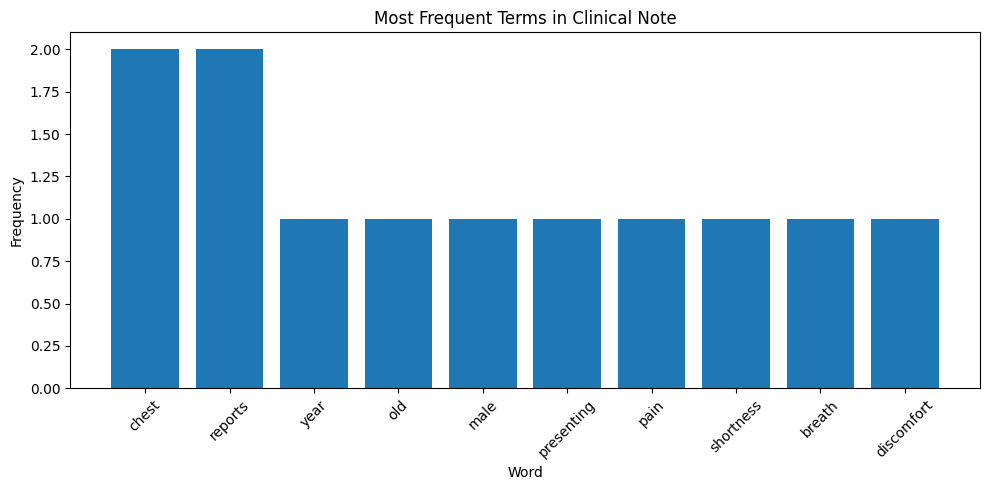

In [50]:
words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(10, 5))

plt.bar(words, counts)

plt.title("Most Frequent Terms in Clinical Note")
plt.xlabel("Word")
plt.ylabel("Frequency")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
print("Clinical Text Analysis")
print("----------------------")
print("Total tokens:", len(tokens))
print("Unique terms:", len(word_frequency))

print("\nKey clinical terms detected:")
for keyword in detected_keywords:
    print("-", keyword)


Clinical Text Analysis
----------------------
Total tokens: 55
Unique terms: 31

Key clinical terms detected:
- ecg
- shortness of breath
- high blood pressure
- dizziness
- chest pain
- elevated cholesterol
- chest discomfort
- fatigue


In [52]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

print("Image libraries imported successfully!")

Image libraries imported successfully!


In [53]:
# Create a synthetic grayscale medical-style image

height = 512
width = 512

# Start with a dark image
image_array = np.zeros((height, width), dtype=np.uint8)

# Create two bright oval regions representing simplified lungs
y, x = np.ogrid[:height, :width]

left_lung = ((x - 180) / 100) ** 2 + ((y - 260) / 180) ** 2 < 1
right_lung = ((x - 332) / 100) ** 2 + ((y - 260) / 180) ** 2 < 1

image_array[left_lung] = 100
image_array[right_lung] = 100

# Add a simple central structure
central_structure = (
    ((x - 256) / 35) ** 2 +
    ((y - 270) / 190) ** 2 < 1
)

image_array[central_structure] = 150

# Convert NumPy array to Pillow image
synthetic_image = Image.fromarray(image_array)

print("Synthetic image created!")

Synthetic image created!


In [54]:
print("Image format:", synthetic_image.format)
print("Image size:", synthetic_image.size)
print("Image mode:", synthetic_image.mode)

Image format: None
Image size: (512, 512)
Image mode: L


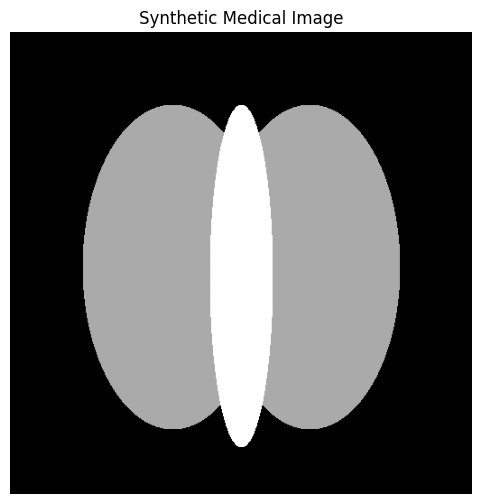

In [55]:
plt.figure(figsize=(6, 6))

plt.imshow(synthetic_image, cmap="gray")

plt.title("Synthetic Medical Image")
plt.axis("off")

plt.show()

In [56]:
synthetic_image.save("synthetic_medical_image.png")

print("Image saved successfully!")

Image saved successfully!


In [57]:
# Load image from file

image = Image.open("synthetic_medical_image.png")

print("Image loaded successfully!")
print("Size:", image.size)
print("Mode:", image.mode)

Image loaded successfully!
Size: (512, 512)
Mode: L


In [58]:
image_array = np.array(image)

print("Array shape:", image_array.shape)
print("Data type:", image_array.dtype)
print("Minimum pixel value:", image_array.min())
print("Maximum pixel value:", image_array.max())

Array shape: (512, 512)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 150


In [59]:
# Resize image

resized_image = image.resize((224, 224))

print("Original size:", image.size)
print("Resized size:", resized_image.size)

Original size: (512, 512)
Resized size: (224, 224)


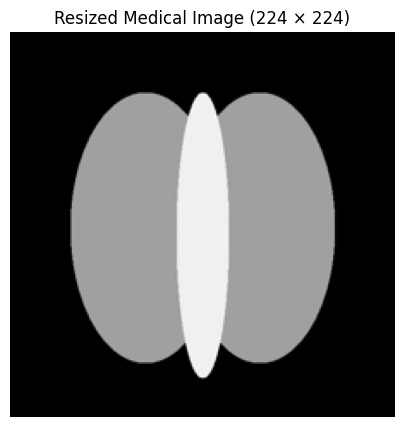

In [60]:
plt.figure(figsize=(5, 5))

plt.imshow(resized_image, cmap="gray")

plt.title("Resized Medical Image (224 × 224)")
plt.axis("off")

plt.show()

In [61]:
print("Image metadata")
print("----------------")
print("Format:", image.format)
print("Size:", image.size)
print("Mode:", image.mode)
print("Width:", image.width)
print("Height:", image.height)

Image metadata
----------------
Format: PNG
Size: (512, 512)
Mode: L
Width: 512
Height: 512


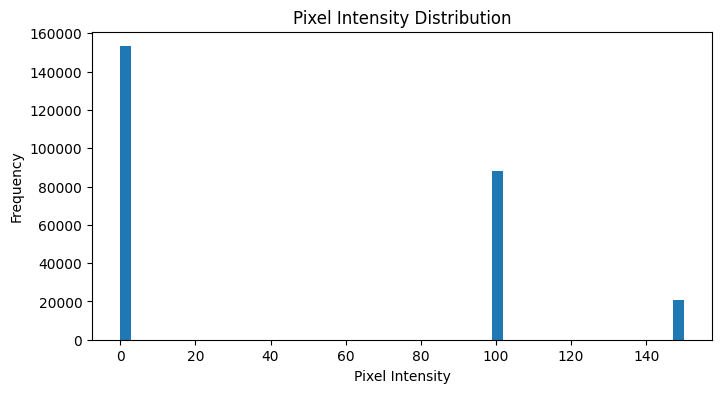

In [62]:
plt.figure(figsize=(8, 4))

plt.hist(image_array.flatten(), bins=50)

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()